In [12]:
# ==========================================
# Ejemplo Clustering Jerárquico
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# --------------------------------------------------
# 1. Crear un dataset simple (2 variables)
# --------------------------------------------------
X = np.array([
    [3, 6],
    [5, 7],
    [8, 1],
    [9, 1],
    [10, 4],
    [11, 5]
])

df = pd.DataFrame(X, columns=["x", "y"])
df


,x,y
0,3,6
1,5,7
2,8,1
3,9,1
4,10,4
5,11,5


In [13]:
# --------------------------------------------------
# 2. Calcular la matriz de distancias
# --------------------------------------------------
dist_matrix = pairwise_distances(X, metric='euclidean')

print("Matriz de Distancias (Euclidiana):")
display(pd.DataFrame(dist_matrix))


Matriz de Distancias (Euclidiana):


,0,1,2,3,4,5
0,0.000000,2.236068,7.071068,7.810250,7.280110,8.062258
1,2.236068,0.000000,6.708204,7.211103,5.830952,6.324555
2,7.071068,6.708204,0.000000,1.000000,3.605551,5.000000
3,7.810250,7.211103,1.000000,0.000000,3.162278,4.472136
4,7.280110,5.830952,3.605551,3.162278,0.000000,1.414214
5,8.062258,6.324555,5.000000,4.472136,1.414214,0.000000


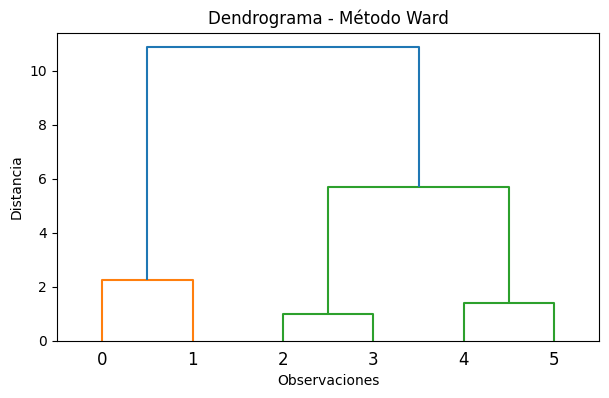

In [14]:
# --------------------------------------------------
# 3. Dendrograma (visualización de la jerarquía)
# --------------------------------------------------
linked = linkage(X, method='ward')

plt.figure(figsize=(7, 4))
dendrogram(linked,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=True)
plt.title("Dendrograma - Método Ward")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()


In [22]:
# --------------------------------------------------
# 4. Aplicar clustering jerárquico
# --------------------------------------------------
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')

labels = cluster.fit_predict(X)
print("Etiquetas asignadas:", labels)


Etiquetas asignadas: [0 0 2 2 1 1]


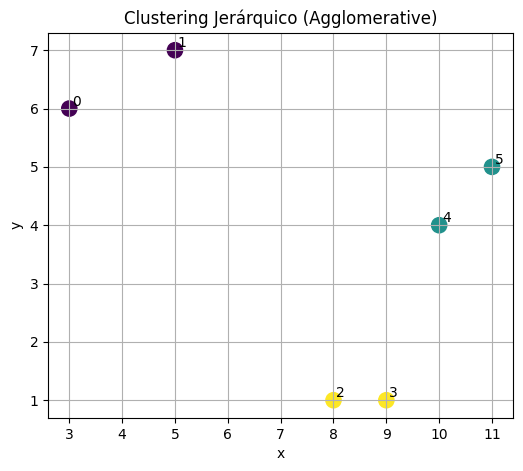

In [24]:
# --------------------------------------------------
# 5. Gráfico de clusters
# --------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=120, cmap="viridis")
plt.title("Clustering Jerárquico (Agglomerative)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
# Añadir las etiquetas para identificar los puntos (opcional)
for i, point in enumerate(X):
    plt.text(point[0]+0.05, point[1]+0.05, str(i))
plt.show()
